# КИМ 4.1. Сверточные сети и перенос обучения — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-04-cnn.ipynb`](./kim-04-cnn.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

---
## Часть А. Свёртка с нуля

Для одноканального изображения операция двумерной свёртки (точнее,
кросс-корреляции, как в большинстве DL-библиотек) имеет вид

$$ (I \star K)[i,j] = \sum_m \sum_n I[i+m,j+n]K[m,n]. $$

Размер выхода равен
$H_{out}=\lfloor(H_{in}-K+2P)/S\rfloor+1$ (аналогично для ширины).

### 0. Импорт библиотек, выбор устройства и фиксация seed

In [1]:
import copy
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import InterpolationMode

%matplotlib inline

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Детерминированность удобна для учебного эксперимента, хотя немного замедляет GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Предупреждение: на CPU полный эксперимент займёт заметно больше 15 минут.')

Устройство: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


### 1. Реализация `conv2d` на NumPy

Функция ниже намеренно использует циклы: это прозрачная реализация формулы, а
не быстрый вариант для обучения сети.

In [2]:
def conv2d(image, kernel, stride=1, padding=0):
    image = np.asarray(image)
    kernel = np.asarray(kernel)
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError('image и kernel должны быть двумерными')
    if stride <= 0 or padding < 0:
        raise ValueError('stride должен быть > 0, padding должен быть >= 0')

    if padding:
        image = np.pad(image, padding, mode='constant')
    height, width = image.shape
    kernel_height, kernel_width = kernel.shape
    out_height = (height - kernel_height) // stride + 1
    out_width = (width - kernel_width) // stride + 1
    if out_height <= 0 or out_width <= 0:
        raise ValueError('ядро больше дополненного изображения')

    output = np.empty((out_height, out_width), dtype=np.result_type(image, kernel))
    for row in range(out_height):
        for col in range(out_width):
            patch = image[
                row * stride:row * stride + kernel_height,
                col * stride:col * stride + kernel_width,
            ]
            output[row, col] = np.sum(patch * kernel)
    return output

# Небольшая проверка на ядре, выделяющем вертикальные границы.
image_5x5 = np.arange(25, dtype=np.float32).reshape(5, 5)
vertical_kernel = np.array([[1, 0, -1],
                            [1, 0, -1],
                            [1, 0, -1]], dtype=np.float32)
result = conv2d(image_5x5, vertical_kernel)
print('Форма результата:', result.shape, '(ожидается (3, 3))')
print(result)

Форма результата: (3, 3) (ожидается (3, 3))
[[-6. -6. -6.]
 [-6. -6. -6.]
 [-6. -6. -6.]]


### 2. Влияние размера ядра, шага и дополнения

In [3]:
sample = np.random.default_rng(SEED).random((32, 32), dtype=np.float32)
experiments = [
    ('kernel=3, stride=1, padding=0', np.ones((3, 3)), 1, 0, (30, 30)),
    ('kernel=5, stride=1, padding=0', np.ones((5, 5)), 1, 0, (28, 28)),
    ('kernel=3, stride=2, padding=0', np.ones((3, 3)), 2, 0, (15, 15)),
    ('kernel=3, stride=1, padding=1', np.ones((3, 3)), 1, 1, (32, 32)),
]

print('Размер входа:', sample.shape)
for name, kernel, stride, padding, expected_shape in experiments:
    actual_shape = conv2d(sample, kernel, stride=stride, padding=padding).shape
    print(f'{name}: {actual_shape}, по формуле: {expected_shape}')
    assert actual_shape == expected_shape

Размер входа: (32, 32)
kernel=3, stride=1, padding=0: (30, 30), по формуле: (30, 30)
kernel=5, stride=1, padding=0: (28, 28), по формуле: (28, 28)
kernel=3, stride=2, padding=0: (15, 15), по формуле: (15, 15)
kernel=3, stride=1, padding=1: (32, 32), по формуле: (32, 32)


---
## Часть Б. Собственная CNN на CIFAR-10

CIFAR-10 содержит 50 000 обучающих и 10 000 тестовых RGB-изображений 32×32.
Обучающую часть делим на 45 000/5 000 объектов. Тестовая выборка не участвует
ни в подборе модели, ни в выборе лучшей эпохи.

### 3. CIFAR-10, преобразования и `DataLoader`

In [4]:
DATA_ROOT = './data'
BATCH_SIZE = 128
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == 'cuda'

# Статистики именно CIFAR-10. Аугментации применяются только к train.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Два объекта одного train-набора нужны, чтобы val не получал случайные аугментации.
train_aug_dataset = datasets.CIFAR10(DATA_ROOT, train=True, download=True,
                                     transform=train_transform)
train_eval_dataset = datasets.CIFAR10(DATA_ROOT, train=True, download=False,
                                      transform=eval_transform)
test_dataset = datasets.CIFAR10(DATA_ROOT, train=False, download=True,
                                transform=eval_transform)

split_generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(train_aug_dataset), generator=split_generator).tolist()
train_indices, val_indices = indices[:45_000], indices[45_000:]
train_dataset = Subset(train_aug_dataset, train_indices)
val_dataset = Subset(train_eval_dataset, val_indices)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader(dataset, batch_size, shuffle):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
    )

train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_dataset, BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f'train/val/test: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}')
print('Один batch:', images.shape, labels.shape)

Using downloaded and verified file: ./data/cifar-10-python.tar.gz
Extracting ./data/cifar-10-python.tar.gz to ./data


Files already downloaded and verified


train/val/test: 45000/5000/10000
Один batch: torch.Size([128, 3, 32, 32]) torch.Size([128])


### 4. VGG-style CNN

Каждый каскад содержит две пары `Conv2d → BatchNorm2d → ReLU`, затем
`MaxPool2d → Dropout2d`. `AdaptiveAvgPool2d` делает классификатор компактным.
Последний слой выдаёт **логиты**: `Softmax` не нужен, потому что
`CrossEntropyLoss` уже включает `LogSoftmax`.

In [5]:
class VGGStyleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def block(in_channels, out_channels, dropout):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout),
            )

        self.features = nn.Sequential(
            block(3, 64, 0.10),   # 32x32 -> 16x16
            block(64, 128, 0.20), # 16x16 -> 8x8
            block(128, 256, 0.30),# 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def count_parameters(model, trainable_only=False):
    parameters = (p for p in model.parameters() if p.requires_grad) if trainable_only                  else model.parameters()
    return sum(p.numel() for p in parameters)

model = VGGStyleCNN().to(device)
print(model)
print(f'Параметров: {count_parameters(model):,}')
with torch.inference_mode():
    print('Форма логитов:', model(images[:2].to(device)).shape)

VGGStyleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tr

Форма логитов: torch.Size([2, 10])


### 5. Циклы обучения и оценки

Loss суммируется с учётом размера batch, поэтому метрики корректны и для
последнего неполного batch. В режиме замороженной ResNet backbone остаётся в
`eval`, чтобы не менять running statistics слоёв BatchNorm.

In [6]:
criterion = nn.CrossEntropyLoss()
USE_AMP = device.type == 'cuda'

def train_one_epoch(model, loader, optimizer, scaler, scheduler=None,
                    frozen_backbone=False):
    if frozen_backbone:
        model.eval()
        model.fc.train()
    else:
        model.train()

    loss_sum = 0.0
    correct = 0
    sample_count = 0
    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        targets = targets.to(device, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(inputs)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        sample_count += batch_size
    return loss_sum / sample_count, correct / sample_count

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        targets = targets.to(device, non_blocking=PIN_MEMORY)
        logits = model(inputs)
        loss = criterion(logits, targets)
        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        sample_count += batch_size
    return loss_sum / sample_count, correct / sample_count

def fit(model, train_loader, val_loader, optimizer, epochs, scheduler=None,
        frozen_backbone=False, phase='model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, scaler, scheduler, frozen_backbone)
        val_loss, val_acc = evaluate(model, val_loader)
        for key, value in (
            ('train_loss', train_loss), ('train_acc', train_acc),
            ('val_loss', val_loss), ('val_acc', val_acc),
        ):
            history[key].append(value)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
        print(f'{phase} | epoch {epoch:02d}/{epochs}: '
              f'train loss={train_loss:.4f}, acc={train_acc:.2%}; '
              f'val loss={val_loss:.4f}, acc={val_acc:.2%}')

    elapsed = time.perf_counter() - started
    model.load_state_dict(best_state)
    print(f'{phase}: лучшая val accuracy={best_val_acc:.2%}, время={elapsed:.1f} с')
    return history, elapsed

### 6. Обучение собственной CNN и кривые

18 эпох с аугментациями и `OneCycleLR` обычно дают более 70% на test и должны
укладываться в 15 минут на современной CUDA GPU. Итог всегда вычисляется по
фактическому запуску, а не подставляется заранее.

/tmp/ipykernel_3752128/3343735184.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_3752128/3343735184.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG-style CNN | epoch 01/18: train loss=1.7571, acc=33.84%; val loss=1.3651, acc=48.94%


VGG-style CNN | epoch 02/18: train loss=1.3526, acc=50.66%; val loss=1.1951, acc=57.56%


VGG-style CNN | epoch 03/18: train loss=1.1765, acc=57.82%; val loss=1.0803, acc=62.58%


VGG-style CNN | epoch 04/18: train loss=1.0338, acc=63.37%; val loss=0.9304, acc=66.92%


...

VGG-style CNN | epoch 15/18: train loss=0.3747, acc=87.30%; val loss=0.3400, acc=88.54%


VGG-style CNN | epoch 16/18: train loss=0.3518, acc=88.17%; val loss=0.3337, acc=88.84%


VGG-style CNN | epoch 17/18: train loss=0.3407, acc=88.27%; val loss=0.3324, acc=88.88%


VGG-style CNN | epoch 18/18: train loss=0.3302, acc=88.82%; val loss=0.3299, acc=88.94%
VGG-style CNN: лучшая val accuracy=88.94%, время=126.7 с


CNN test loss=0.3437, test accuracy=88.37%


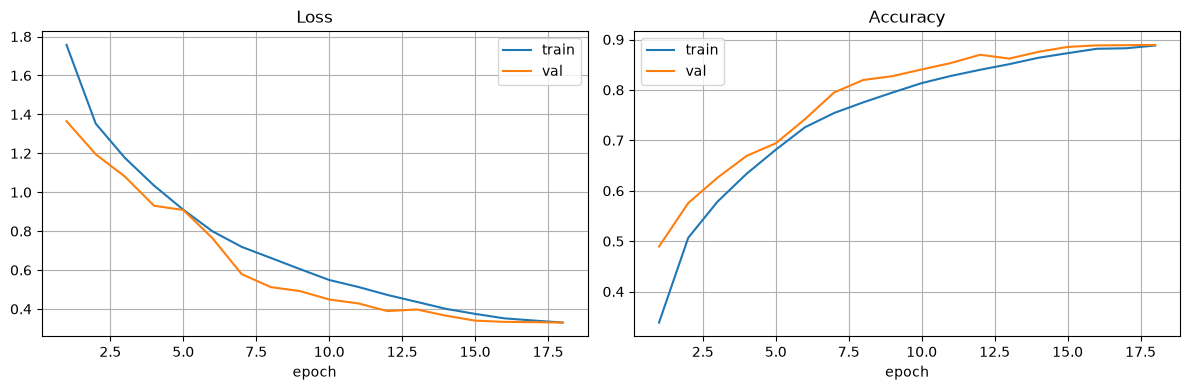

In [7]:
CNN_EPOCHS = 18
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    epochs=CNN_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.20,
)

cnn_history, cnn_train_seconds = fit(
    model, train_loader, val_loader, optimizer, CNN_EPOCHS,
    scheduler=scheduler, phase='VGG-style CNN')
cnn_test_loss, cnn_test_acc = evaluate(model, test_loader)
cnn_trainable_parameters = count_parameters(model, trainable_only=True)
print(f'CNN test loss={cnn_test_loss:.4f}, test accuracy={cnn_test_acc:.2%}')
if cnn_test_acc < 0.65:
    print('Цель 65% не достигнута: проверьте, что обучение шло на всех 18 эпохах.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, CNN_EPOCHS + 1)
axes[0].plot(epochs, cnn_history['train_loss'], label='train')
axes[0].plot(epochs, cnn_history['val_loss'], label='val')
axes[0].set(title='Loss', xlabel='epoch')
axes[1].plot(epochs, cnn_history['train_acc'], label='train')
axes[1].plot(epochs, cnn_history['val_acc'], label='val')
axes[1].set(title='Accuracy', xlabel='epoch')
for axis in axes:
    axis.grid(True)
    axis.legend()
plt.tight_layout()
plt.show()

---
## Часть В. Transfer learning на CIFAR-10

Используем `ResNet18_Weights.DEFAULT`, то есть актуальный API torchvision.
При первом запуске веса ImageNet автоматически скачиваются в кэш Torch Hub
(нужен доступ в интернет), затем используются локально. Предобученная ResNet18
ожидает ImageNet-нормализацию и вход 224×224, поэтому для неё создаются отдельные
датасеты и загрузчики, но используются те же train/val индексы.

### 7. ImageNet-преобразования и предобученная ResNet18

In [8]:
weights = ResNet18_Weights.DEFAULT
imagenet_eval_transform = weights.transforms()
imagenet_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224, scale=(0.75, 1.0), interpolation=InterpolationMode.BILINEAR,
        antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_eval_transform.mean,
        std=imagenet_eval_transform.std,
    ),
])

tl_train_base = datasets.CIFAR10(DATA_ROOT, train=True, download=False,
                                 transform=imagenet_train_transform)
tl_val_base = datasets.CIFAR10(DATA_ROOT, train=True, download=False,
                               transform=imagenet_eval_transform)
tl_test_dataset = datasets.CIFAR10(DATA_ROOT, train=False, download=False,
                                   transform=imagenet_eval_transform)
tl_train_dataset = Subset(tl_train_base, train_indices)
tl_val_dataset = Subset(tl_val_base, val_indices)

# AMP снижает расход памяти; 128 обычно подходит для ResNet18. При нехватке VRAM
# достаточно уменьшить только эту константу до 64.
TL_BATCH_SIZE = 128
tl_train_loader = make_loader(tl_train_dataset, TL_BATCH_SIZE, shuffle=True)
tl_val_loader = make_loader(tl_val_dataset, TL_BATCH_SIZE, shuffle=False)
tl_test_loader = make_loader(tl_test_dataset, TL_BATCH_SIZE, shuffle=False)

try:
    transfer_model = resnet18(weights=weights)
except Exception as error:
    raise RuntimeError(
        'Не удалось получить веса ResNet18. Проверьте интернет или кэш Torch Hub '
        '(обычно ~/.cache/torch/hub/checkpoints).'
    ) from error

print('Категории исходных весов:', len(weights.meta['categories']))
print('Eval transforms:', imagenet_eval_transform)

Категории исходных весов: 1000
Eval transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 8. Feature extraction: замораживаем backbone

Сначала у всех исходных параметров устанавливаем `requires_grad=False`, затем
заменяем `fc`. Новый слой создаётся обучаемым, и оптимизатор получает только его
параметры. В этой фазе backbone выполняет только извлечение признаков.

In [ ]:
for parameter in transfer_model.parameters():
    parameter.requires_grad = False

in_features = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(in_features, 10)
transfer_model = transfer_model.to(device)

head_trainable_parameters = count_parameters(transfer_model, trainable_only=True)
print(f'Всего параметров: {count_parameters(transfer_model):,}')
print(f'Обучаемых при заморозке: {head_trainable_parameters:,}')
assert all(not p.requires_grad for name, p in transfer_model.named_parameters()
           if not name.startswith('fc.'))

HEAD_EPOCHS = 3
head_optimizer = torch.optim.Adam(
    (p for p in transfer_model.parameters() if p.requires_grad), lr=1e-3)
head_history, head_train_seconds = fit(
    transfer_model, tl_train_loader, tl_val_loader, head_optimizer,
    HEAD_EPOCHS, frozen_backbone=True, phase='ResNet18 head')
head_val_loss, head_val_acc = evaluate(transfer_model, tl_val_loader)
head_test_loss, head_test_acc = evaluate(transfer_model, tl_test_loader)
print(f'Frozen backbone: test loss={head_test_loss:.4f}, '
      f'test accuracy={head_test_acc:.2%}')

### 9. Fine-tuning всей сети

Теперь размораживаем backbone и создаём **новый** Adam с требуемым малым
`lr=1e-5`. Новый оптимизатор важен: старый вообще не содержал параметры
backbone. Низкий learning rate аккуратно адаптирует ImageNet-признаки к CIFAR-10
и уменьшает риск catastrophic forgetting.

In [ ]:
for parameter in transfer_model.parameters():
    parameter.requires_grad = True

fine_tune_trainable_parameters = count_parameters(
    transfer_model, trainable_only=True)
print(f'Обучаемых после разморозки: {fine_tune_trainable_parameters:,}')

FINE_TUNE_EPOCHS = 3
fine_tune_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=1e-5)
fine_tune_history, fine_tune_seconds = fit(
    transfer_model, tl_train_loader, tl_val_loader, fine_tune_optimizer,
    FINE_TUNE_EPOCHS, frozen_backbone=False, phase='ResNet18 fine-tune')
fine_tune_val_loss, fine_tune_val_acc = evaluate(
    transfer_model, tl_val_loader)
fine_tune_test_loss, fine_tune_test_acc = evaluate(
    transfer_model, tl_test_loader)
print(f'Fine-tuned: test loss={fine_tune_test_loss:.4f}, '
      f'test accuracy={fine_tune_test_acc:.2%}')

**Почему не `lr=0.01`?** Предобученный backbone уже хранит полезные
универсальные признаки. Большой шаг быстро и одновременно изменит миллионы его
весов, разрушая эти признаки (catastrophic forgetting); качество может резко
упасть. `lr=1e-5` вносит малые поправки под новый домен.

Как и у собственной CNN, ResNet возвращает логиты. Перед
`nn.CrossEntropyLoss()` **нет Softmax**; вероятности нужны только для отдельной
интерпретации предсказаний, где можно вызвать `logits.softmax(dim=1)`.

### 10. Фактическое сравнение результатов

In [11]:
rows = [
    ('VGG-style CNN', cnn_test_acc, cnn_train_seconds, cnn_trainable_parameters),
    ('ResNet18: frozen', head_test_acc, head_train_seconds, head_trainable_parameters),
    ('ResNet18: fine-tuned', fine_tune_test_acc,
     head_train_seconds + fine_tune_seconds, fine_tune_trainable_parameters),
]

print(f"{'Модель':<24} {'test acc':>10} {'время, с':>12} {'обуч. параметры':>20}")
print('-' * 70)
for name, accuracy, seconds, parameters in rows:
    print(f'{name:<24} {accuracy:>9.2%} {seconds:>12.1f} {parameters:>20,}')

improvement = fine_tune_test_acc - head_test_acc
print(f'Изменение test accuracy после fine-tuning: {improvement:+.2%}')

Модель                     test acc     время, с      обуч. параметры
----------------------------------------------------------------------
VGG-style CNN               88.37%        126.7            1,214,666
ResNet18: frozen            84.84%         90.6                5,130
ResNet18: fine-tuned        90.98%        330.2           11,181,642
Изменение test accuracy после fine-tuning: +6.14%


---
## Часть Г. Transfer learning на малой выборке

Для каждого класса выбираем ровно 20 train-изображений. Validation и test
остаются полными и не используются при формировании few-shot-выборки.

In [ ]:
targets = np.asarray(train_eval_dataset.targets)
rng = np.random.default_rng(SEED)
fewshot_indices = []
train_index_set = np.asarray(train_indices)
for class_id in range(10):
    class_indices = train_index_set[targets[train_index_set] == class_id].copy()
    rng.shuffle(class_indices)
    fewshot_indices.extend(class_indices[:20].tolist())

fewshot_dataset = Subset(tl_train_base, fewshot_indices)
fewshot_loader = make_loader(fewshot_dataset, batch_size=64, shuffle=True)
print('Few-shot объектов:', len(fewshot_dataset))
print('Баланс:', np.bincount(targets[fewshot_indices], minlength=10))

fewshot_model = resnet18(weights=weights)
for parameter in fewshot_model.parameters():
    parameter.requires_grad = False
fewshot_model.fc = nn.Linear(fewshot_model.fc.in_features, 10)
fewshot_model = fewshot_model.to(device)

fewshot_head_optimizer = torch.optim.Adam(fewshot_model.fc.parameters(), lr=1e-3)
fewshot_head_history, fewshot_head_seconds = fit(
    fewshot_model, fewshot_loader, tl_val_loader, fewshot_head_optimizer,
    epochs=5, frozen_backbone=True, phase='Few-shot frozen head')
fewshot_head_val_loss, fewshot_head_val_acc = evaluate(
    fewshot_model, tl_val_loader)
fewshot_head_test_loss, fewshot_head_test_acc = evaluate(
    fewshot_model, tl_test_loader)

for parameter in fewshot_model.parameters():
    parameter.requires_grad = True
fewshot_fine_optimizer = torch.optim.Adam(fewshot_model.parameters(), lr=1e-5)
fewshot_fine_history, fewshot_fine_seconds = fit(
    fewshot_model, fewshot_loader, tl_val_loader, fewshot_fine_optimizer,
    epochs=3, frozen_backbone=False, phase='Few-shot fine-tune')
fewshot_fine_val_loss, fewshot_fine_val_acc = evaluate(
    fewshot_model, tl_val_loader)
fewshot_fine_test_loss, fewshot_fine_test_acc = evaluate(
    fewshot_model, tl_test_loader)

fewshot_rows = [
    ('20/class: frozen', fewshot_head_val_acc, fewshot_head_test_acc,
     fewshot_head_seconds),
    ('20/class: fine-tuned', fewshot_fine_val_acc, fewshot_fine_test_acc,
     fewshot_head_seconds + fewshot_fine_seconds),
    ('full train: frozen', head_val_acc, head_test_acc, head_train_seconds),
    ('full train: fine-tuned', fine_tune_val_acc, fine_tune_test_acc,
     head_train_seconds + fine_tune_seconds),
]
print(f"{'Режим':<25} {'val acc':>10} {'test acc':>10} {'время, с':>12}")
for name, val_accuracy, test_accuracy, seconds in fewshot_rows:
    print(f'{name:<25} {val_accuracy:>9.2%} {test_accuracy:>9.2%} '
          f'{seconds:>12.1f}')

На малой выборке замороженный backbone уменьшает число обучаемых
параметров и риск переобучения. Fine-tuning может улучшить соответствие домену,
но при 20 объектах класса требует малого learning rate и контроля validation.

---
## Часть Д. YOLO и видеопайплайн OpenCV

Эта часть требует `ultralytics` и OpenCV. При первом запуске скачиваются веса
YOLO и открытое тестовое изображение. Из изображения создаётся короткое видео,
чтобы весь конвейер оставался воспроизводимым без внешнего видеофайла.

In [ ]:
import subprocess
import sys
import urllib.request
from pathlib import Path

try:
    import cv2
    from ultralytics import YOLO
except ImportError:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'ultralytics', 'opencv-python-headless',
    ])
    import cv2
    from ultralytics import YOLO

pipeline_dir = Path('data/cv_pipeline')
pipeline_dir.mkdir(parents=True, exist_ok=True)
image_path = pipeline_dir / 'bus.jpg'
source_video_path = pipeline_dir / 'source.mp4'
annotated_video_path = pipeline_dir / 'detections.mp4'
saved_model_path = pipeline_dir / 'yolo11n-course.pt'

if not image_path.exists():
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', image_path)

frame = cv2.imread(str(image_path))
if frame is None:
    raise RuntimeError(f'OpenCV не прочитал {image_path}')
height, width = frame.shape[:2]
fps = 10
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# Воспроизводимое короткое видео: плавный горизонтальный сдвиг тестового кадра.
source_writer = cv2.VideoWriter(
    str(source_video_path), fourcc, fps, (width, height))
for shift in np.linspace(-30, 30, 30).astype(int):
    transform = np.float32([[1, 0, shift], [0, 1, 0]])
    shifted = cv2.warpAffine(frame, transform, (width, height),
                             borderMode=cv2.BORDER_REFLECT)
    source_writer.write(shifted)
source_writer.release()

yolo = YOLO('yolo11n.pt')
capture = cv2.VideoCapture(str(source_video_path))
annotated_writer = cv2.VideoWriter(
    str(annotated_video_path), fourcc, fps, (width, height))
processed_frames = 0
while True:
    ok, video_frame = capture.read()
    if not ok:
        break
    result = yolo.predict(video_frame, verbose=False)[0]
    annotated_writer.write(result.plot())
    processed_frames += 1
capture.release()
annotated_writer.release()

yolo.save(str(saved_model_path))
reloaded_yolo = YOLO(str(saved_model_path))
before = yolo.predict(frame, verbose=False)[0]
after = reloaded_yolo.predict(frame, verbose=False)[0]
before_classes = before.boxes.cls.cpu().numpy().astype(int)
after_classes = after.boxes.cls.cpu().numpy().astype(int)
before_confidence = before.boxes.conf.cpu().numpy()
after_confidence = after.boxes.conf.cpu().numpy()
assert np.array_equal(before_classes, after_classes)
assert np.allclose(before_confidence, after_confidence, atol=1e-5)

print('Обработано кадров:', processed_frames)
print('Классы контрольного кадра:', before_classes.tolist())
print('Размеченное видео:', annotated_video_path)
print('Сохранённая модель:', saved_model_path)

`VideoCapture` последовательно читает кадры, YOLO возвращает боксы,
классы и confidence, `result.plot()` формирует размеченный кадр, а
`VideoWriter` собирает кадры в новый файл. Проверка после повторной загрузки
защищает от ситуации, когда сохранён не тот checkpoint или изменилась
конфигурация модели.

---
## Итог

В решении есть NumPy-реализация свёртки, собственная VGG-style CNN с настоящими
циклами train/eval, transfer learning ResNet18 на полной и малой выборках, а
также YOLO-видеопайплайн с OpenCV и проверкой save/load. Все табличные значения
получаются при запуске; test нигде не используется для обучения или выбора
лучшей эпохи.